# Blockchain explorer — on-chain reconnaissance canvas

Interactive notebook for crawling smart contracts and their participants directly from the chain. Built on top of `harness.explorer`, which wraps:

* **Sourcify** (no auth) + **Etherscan v2** (multichain, `ETHERSCAN_API_KEY` required for tx history)
* **Public JSON-RPC** (LlamaRPC defaults, override per-chain via `W3S_RPC_<chain-id>`)
* The full `web3Sentinel` corpus (8,400+ findings) for grounding what you see

**Typical workflow:** paste an address → see the deployment metadata → see who interacted with it → graph the participants → identify interesting EOAs/contracts → hand the highest-priority address off to `w3s audit` for a full security review.

## Setup

Set `ETHERSCAN_API_KEY` first (free tier at https://etherscan.io/myapikey). Without it, source fetch + proxy resolution still work (Sourcify only); tx history / participants / token flows do not.

In [12]:
import os
import sys
from pathlib import Path

# Make sure the repo root is importable (notebooks live one dir below).
REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

from harness import explorer
from harness.onchain import CHAIN_NAMES

# Optional: load .env if present (won't override existing env vars).
env_file = REPO_ROOT / '.env'
if env_file.exists():
    for line in env_file.read_text().splitlines():
        if line.strip() and not line.startswith('#') and '=' in line:
            k, v = line.split('=', 1)
            os.environ.setdefault(k.strip(), v.strip())

print(f"ETHERSCAN_API_KEY     : {'set' if os.environ.get('ETHERSCAN_API_KEY') else 'NOT SET (tx history will fail)'}")
print(f"chains supported      : {', '.join(CHAIN_NAMES.values())}")
print(f"etherscan rate cap    : {1.0/explorer._MIN_INTERVAL:.1f} req/sec (override via W3S_ETHERSCAN_RPS)")
print(f"calls so far this run : {explorer.call_count()}  -- re-run `explorer.call_count()` anytime")

ETHERSCAN_API_KEY     : set
chains supported      : mainnet, optimism, polygon, arbitrum, base, sepolia
etherscan rate cap    : 3.0 req/sec (override via W3S_ETHERSCAN_RPS)
calls so far this run : 8  -- re-run `explorer.call_count()` anytime


## Pick a target

Try one of these starter addresses, or paste your own:

In [2]:
# A few well-known mainnet contracts to play with.
EXAMPLES = {
    'Uniswap V3 SwapRouter02': '0x68b3465833fb72A70ecDF485E0e4C7bD8665Fc45',
    'Aave V3 Pool':            '0x87870Bca3F3fD6335C3F4ce8392D69350B4fA4E2',
    'USDC (proxy)':            '0xA0b86991c6218b36c1d19D4a2e9Eb0cE3606eB48',
    'EulerSwap factory':       '0xb013BAa3CC9C8FfdE3B2cC78b0C13B2c4F4Fc04A',
}

TARGET   = EXAMPLES['Uniswap V3 SwapRouter02']
CHAIN    = 'mainnet'   # mainnet | optimism | polygon | arbitrum | base | sepolia | <chain-id>

print(f'Target: {TARGET} on {CHAIN}')

Target: 0x68b3465833fb72A70ecDF485E0e4C7bD8665Fc45 on mainnet


## Step 1 — Deployment metadata

Who deployed it, when, with which compiler, is it a proxy?

In [3]:
info = explorer.get_deployment_info(TARGET, chain=CHAIN)
print(f'address       : {info.address}')
print(f'chain         : {info.chain_name} ({info.chain_id})')
print(f'contract name : {info.contract_name}')
print(f'compiler      : {info.compiler}')
print(f'creator EOA   : {info.creator}')
print(f'creation tx   : {info.creation_tx}')
print(f'is proxy      : {info.is_proxy}  impl: {info.implementation}')
print(f'source files  : {len(info.source_files)} via {info.source_via}')
for p in list(info.source_files.keys())[:8]:
    print(f'    {p}')

address       : 0x68b3465833fb72A70ecDF485E0e4C7bD8665Fc45
chain         : mainnet (1)
contract name : SwapRouter02
compiler      : 0.7.6+commit.7338295f
creator EOA   : 0x6c9fc64a53c1b71fb3f9af64d1ae3a4931a5f4e9
creation tx   : 0x7299cca7203f60a831756e043f4c2ccb0ee6cb7cf8aed8420f0ae99a16883a2b
is proxy      : False  impl: None
source files  : 236 via sourcify-any
    contracts/SwapRouter02.sol
    contracts/V2SwapRouter.sol
    contracts/V3SwapRouter.sol
    contracts/base/ApproveAndCall.sol
    contracts/base/ImmutableState.sol
    contracts/base/OracleSlippage.sol
    contracts/libraries/Constants.sol
    contracts/base/MulticallExtended.sol


## Step 2 — Recent participants (who calls this thing?)

Returns a table of unique callers sorted by call count, with ETH sent + block range.

In [4]:
import pandas as pd
pd.set_option('display.max_rows', 30)

parts = explorer.participants(TARGET, chain=CHAIN, n=500)
print(f'Unique participants in last 500 txs: {len(parts)}')
parts.head(20)

Unique participants in last 500 txs: 87


,calls,eth_value_sent_wei,first_block,last_block
from,,,,
0xf9b6a1eb0190bf76274b0876957ee9f4f508af41,186,0,25115347,25117109
0x1dc89ab25ab5d8714fcf9ee4bd9c9a58debeb4d8,25,0,25115339,25117120
0xe917e3fb7b40e3d4c8522fa63137842f53ddc45d,23,84695390287572674,25115911,25117077
0xfb13cf5020454f01ee24a0d38833093c2dd98189,18,0,25115383,25117118
0x8b40035f31907f326910539284ba2aaf64e90a27,18,0,25115383,25117037
0x2b38ec627855086fb21ef3ae9e7042f84584a51b,17,0,25115356,25117092
0x80f816ae67a0fdece85c918c653fa0e9d50de0fc,16,0,25115335,25117113
0xcdddbcb65f01d7696ecca0e635f425ce4d429010,12,0,25115340,25117113
0x38d79c76271bb2e7bf3ac28c8a78fc5ef83c218a,12,0,25115494,25116981


## Step 3 — Token flows (ERC20)

Transfer events where the target appears as `from` or `to`. Surfaces which tokens move through this contract.

In [5]:
tt = explorer.token_transfers(TARGET, chain=CHAIN, n=500, kind='erc20')
if tt.empty:
    print('(no ERC20 transfers for this address)')
else:
    by_token = tt.groupby('tokenSymbol').agg(transfers=('hash', 'count'), unique_counterparties=('from', 'nunique')).sort_values('transfers', ascending=False)
    print('Top tokens flowing through this contract:')
    print(by_token.head(10))
    tt.head(10)[['blockNumber', 'from', 'to', 'tokenSymbol', 'value']]

Top tokens flowing through this contract:
             transfers  unique_counterparties
tokenSymbol                                  
WETH               424                     23
USDC                32                      7
USDT                18                      6
DAI                  6                      4
RNDR                 6                      3
FET                  4                      3
N                    4                      2
wstETH               4                      3
RFD                  2                      2


## Step 4 — What does this contract call? (1-hop call graph)

Uses Etherscan's internal-tx endpoint to see addresses this contract has invoked. Useful for spotting upstream dependencies (oracle, vault, factory).

In [7]:
out = explorer.outgoing_call_targets(TARGET, chain=CHAIN, n=200)
if out.empty:
    print('(no outbound calls — pure storage contract, or txlistinternal returned nothing)')
else:
    print(f'{len(out)} unique downstream contracts called by this address:')
    out.head(20)

20 unique downstream contracts called by this address:


## Step 5 — Related contracts (creator's other deployments)

Walks the deployer's transaction history and filters contract-creation txs. Tells you the rest of this protocol's surface.

In [8]:
if info.creator:
    deploys = explorer.creator_deployments(info.creator, chain=CHAIN, n=1000)
    print(f"{len(deploys)} other contracts deployed by {info.creator}")
    for d in deploys[:10]:
        print(f"  block {d.get('blockNumber','?'):>10}  {d.get('contractAddress')}  (tx {d.get('hash','?')[:10]}...)")
else:
    print('No creator info available; skipping.')

14 other contracts deployed by 0x6c9fc64a53c1b71fb3f9af64d1ae3a4931a5f4e9
  block   13804681  0x68b3465833fb72a70ecdf485e0e4c7bd8665fc45  (tx 0x7299cca7...)
  block   13723980  0x61ffe014ba17989e743c5f6cb21bf9697530b21e  (tx 0xff27d294...)
  block   13723978  0x075b36de1bd11cb361c5b3b1e80a9ab0e7aa8a60  (tx 0x29a626a3...)
  block   13672703  0xa9bf398e74da1ac6f5c4cb67ab8937c10a1e454d  (tx 0x50874a69...)
  block   12369654  0xa5644e29708357803b5a882d272c41cc0df92b34  (tx 0x399fa9a4...)
  block   12369651  0xc36442b4a4522e871399cd717abdd847ab11fe88  (tx 0xc5eabeff...)
  block   12369648  0xee6a57ec80ea46401049e92587e52f5ec1c24785  (tx 0x453325d7...)
  block   12369645  0x91ae842a5ffd8d12023116943e72a606179294f3  (tx 0xc7342e5a...)
  block   12369642  0x42b24a95702b9986e82d421cc3568932790a48ec  (tx 0xb722fce9...)
  block   12369634  0xe592427a0aece92de3edee1f18e0157c05861564  (tx 0xe881c43c...)


## Step 6 — Participant graph (visualize)

Builds a NetworkX directed graph of callers → target → downstream contracts. EOAs yellow, contracts indigo.

graph: 35 nodes, 36 edges


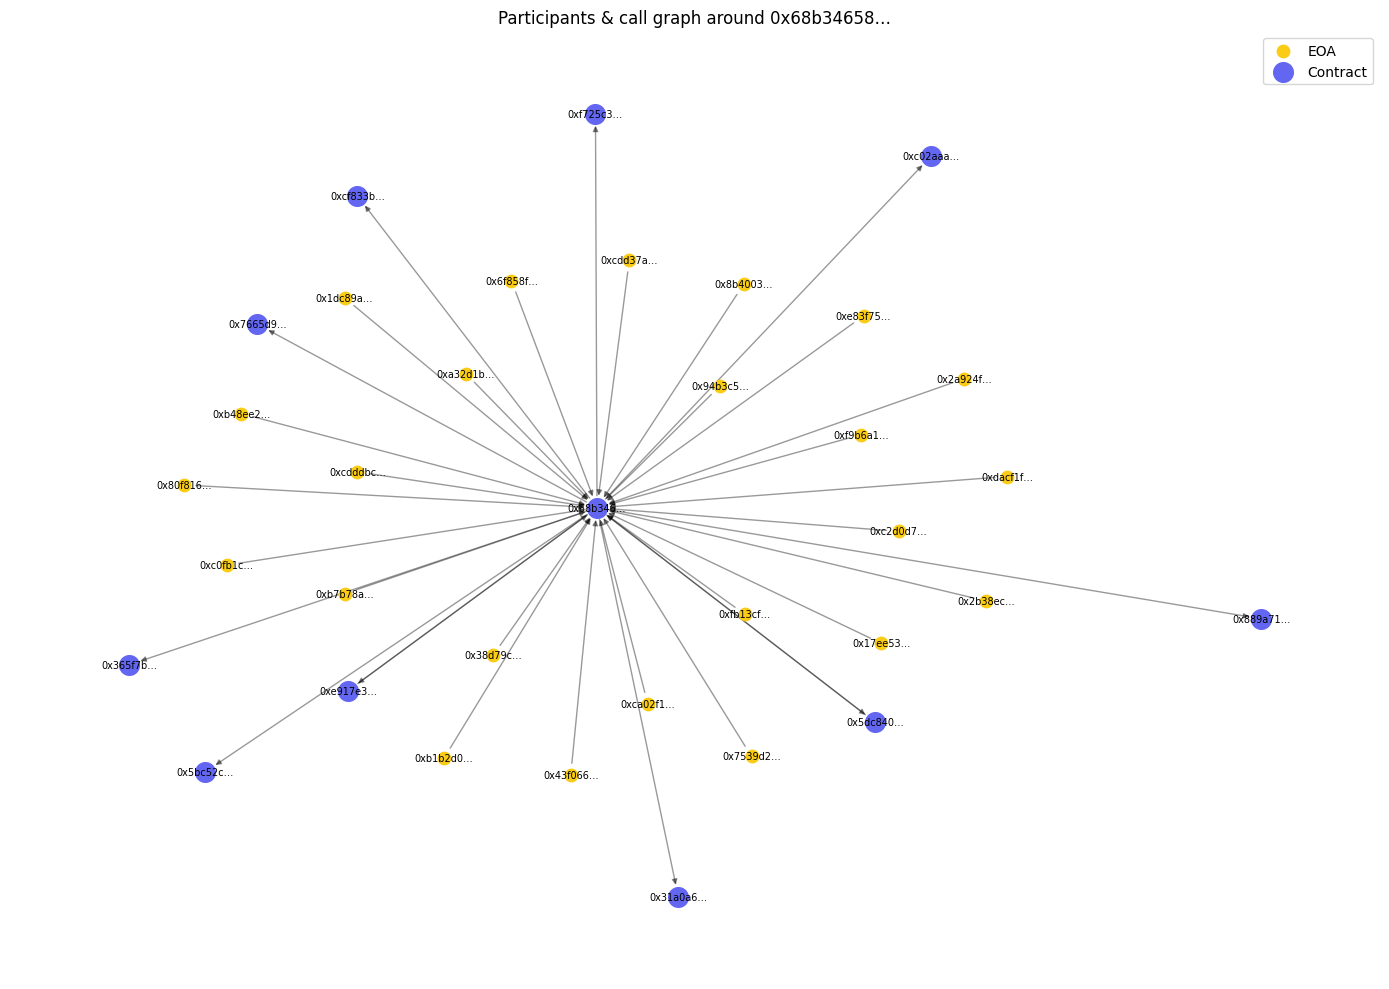

In [9]:
import matplotlib.pyplot as plt

G, meta = explorer.participant_graph(TARGET, chain=CHAIN, n=100, include_internal=True)
print(f'graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')

fig, ax = plt.subplots(figsize=(14, 10))
explorer.draw_graph(G, meta, ax=ax)
ax.set_title(f'Participants & call graph around {TARGET[:10]}…')
plt.tight_layout()
plt.show()

## Step 7 — Cross-reference with the corpus

Now that we know what this contract does and who interacts with it, check our 8,400+ corpus for related prior findings.

In [10]:
from harness import corpus

# Build a query from the contract name + any token tickers we saw
query_parts = []
if info.contract_name:
    query_parts.append(info.contract_name)
if 'tt' in dir() and not tt.empty:
    query_parts.extend(tt['tokenSymbol'].dropna().unique()[:3].tolist())
query = ' '.join(query_parts) or 'router swap liquidity'

hits = corpus.search(query, top_k=10)
print(f'Corpus search for: "{query}"\n')
for h in hits:
    sev = (h.severity or '—')[:4].ljust(4)
    print(f'  [{sev}] [{h.source}] {h.id[:50]}  ::  {h.title[:60]}')

Corpus search for: "SwapRouter02 WETH USDT USDC"

  [High] [solodit] solodit-zokyo-2023-06-16-umami-0-0  ::  Price manipulation through Uniswap pool
  [Medi] [solodit] solodit-zokyo-2024-04-19-gumball-0-0  ::  Calculations Not Compatible With USDC/USDT
  [Crit] [rekt] rekt-beanstalk-rekt  ::  Beanstalk - REKT
  [Crit] [rekt] rekt-popsicle-rekt  ::  Popsicle Finance - REKT
  [Crit] [rekt] rekt-warp-finance-rekt  ::  Warp Finance - REKT
  [Low ] [solodit] solodit-zokyo-2022-10-13-thestandard-io-1-1  ::  Incomplete removal of multiply-added tokens in TokenManager.
  [Low ] [solodit] solodit-zokyo-2024-06-09-elektrik-2-0  ::  USE A MULTISIG ACCOUNT FOR THE OWNER
  [Medi] [solodit] solodit-zokyo-2024-06-09-elektrik-1-4  ::  `getUsdPrice` WILL NOT WORK WITH COMPLEX/LARGE PATHS
  [Medi] [solodit] solodit-cyfrin-2023-06-07-cyfrin-uniswap-v3-limit-  ::  New orders on a given pool in the opposite direction, separa
  [Info] [solodit] solodit-cyfrin-2025-07-25-cyfrin-myriad-v2-0-1-2  ::  Consider 

## Step 8 — Hand-off to the audit harness

Pick the most interesting contract (the target itself, an implementation address, or a sibling contract from the creator's deployments) and audit it with the full harness:

```bash
# From the repo root:
.venv/bin/w3s audit <address> --chain mainnet              # single-model, ~$1-2
.venv/bin/w3s audit <address> --chain mainnet --multimodel # claude + codex + reconciler, ~$5-7
```

Or stay in the notebook and shell out:

In [ ]:
# Uncomment to run an audit from inside the notebook:
# import subprocess
# subprocess.run(['.venv/bin/w3s', 'audit', TARGET, '--chain', CHAIN, '--no-pocs'],
#                cwd=str(REPO_ROOT), check=False)

## Step 9 — Replay a specific transaction

If one of the participants did something suspicious, replay their tx in an Anvil sandbox to see the full call trace + state diffs.

In [11]:
from harness.trace import replay_tx

# Example: pick the most recent tx hash from the participants table
# tx_hash = '0x...'
# trace = replay_tx(tx_hash, chain=CHAIN)
# print(trace.trace_text[:3000])  # head of the trace

## Notes / extensions

* **Free-tier API limits**: Etherscan free tier is 5 req/sec / 100k req/day — plenty for exploratory work; rate-limit yourself if you script wider crawls.
* **Multi-chain in one notebook**: change `CHAIN` between cells; the explorer module routes the request to the right Etherscan multichain endpoint.
* **Bytecode similarity** (not yet implemented): for clustering forks/copies, hash deployed bytecode and group near-matches.
* **Persistent canvas**: any address worth tracking, save it to `notebooks/_watchlist.json` and re-run this notebook against your list weekly.
* **Hand-off to the auditor**: every cell's output is a candidate input. The most useful chain is: target → its dependencies (via outgoing_call_targets) → audit each one ranked by interaction volume.